In [1]:
#12 聚类分析算法
#12.1 载入分析所需要的库和模块
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [ ]:
#12.2 变量设置及数据处理
data=pd.read_csv('数据12.1.csv')
X = data.iloc[:,[1,3,4,8]]#设置分析所需要的特征变量
print(f'info:{X.info()}')#查看数据基本信息
print(f'len:{len(X.columns)}')#查看变量个数
print(f'columns:{X.columns}')#查看变量名称
print(f'shape:{X.shape}')#  查看数据形状
X.isnull().values.any() 
X.isnull().sum() 
scaler = StandardScaler()#数据标准化
scaler.fit(X)#  拟合标准化模型
X_s = scaler.transform(X)#  数据标准化转换
X_s = pd.DataFrame(X_s, columns=X.columns)#    转换为DataFrame格式
print(X_s.head(10))#查看前10行标准化后的数据

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V2      28 non-null     int64  
 1   V4      28 non-null     float64
 2   V5      28 non-null     float64
 3   V9      28 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.0 KB
info:None
len:4
columns:Index(['V2', 'V4', 'V5', 'V9'], dtype='object')
shape:(28, 4)
         V2        V4        V5        V9
0  3.331341  2.770017  3.405459  3.989002
1 -0.373910  0.034349 -0.259663 -0.452757
2 -0.546248 -0.692313 -0.631462 -0.589194
3 -0.589332 -0.606824 -0.631462 -0.498035
4 -0.632416 -0.649569 -0.590530 -0.603985
5 -0.201573 -0.371727 -0.094229  0.987683
6 -0.589332 -0.670941 -0.651928 -0.571385
7  0.013849  0.483169  0.188884  0.103557
8  0.573945  0.333562  0.463470  0.434387
9 -0.416995 -0.350355 -0.361993 -0.312698


          V2        V4        V5        V9
V2  1.000000  0.946057  0.966842  0.938237
V4  0.946057  1.000000  0.977966  0.879125
V5  0.966842  0.977966  1.000000  0.938684
V9  0.938237  0.879125  0.938684  1.000000


<Axes: >

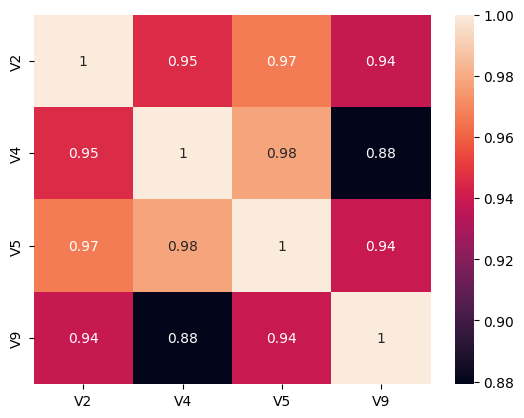

In [ ]:
#12.3 相关性分析
print(X_s.corr(method='pearson'))  
plt.subplot(1,1,1)
sns.heatmap(X_s.corr(), annot=True)

In [ ]:
#12.4 使用K均值聚类分析方法对样本示例进行聚类(K=2)
model = KMeans(n_clusters=2, random_state=2)#   建立K均值聚类模型对象
model.fit(X_s)# 模型拟合
print(model.labels_)#  查看聚类结果
pd.DataFrame(model.labels_.T, index=data.V1,columns=['聚类'])   #  将聚类结果与样本编号合并显示
print(model.cluster_centers_)   # 查看各聚类中心
print(model.inertia_)       # 查看簇内误差平方和

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
[[-0.31703902 -0.32128836 -0.31696734 -0.29871581]
 [ 2.64199186  2.67740299  2.64139452  2.48929838]]
20.19747784718668


In [13]:
#12.5 使用K均值聚类分析方法对样本示例进行聚类(K=3)
model = KMeans(n_clusters=3, random_state=2)    #建立K均值聚类模型对象
model.fit(X_s)                  #模型拟合
print(model.labels_)        #查看聚类结果
pd.DataFrame(model.labels_.T, index=data.V1,columns=['聚类'])       #将聚类结果与样本编号合并显示
np.set_printoptions(suppress=True)#不以科学计数法显示，而是直接显示数字
print(model.cluster_centers_)  #查看各聚类中心
print(model.inertia_)       #查看簇内误差平方和

[1 0 2 2 2 0 2 0 0 2 0 2 0 2 0 0 2 2 0 0 2 2 2 2 2 2 1 1]
[[ 0.03539069  0.10060298  0.10633798  0.01837419]
 [ 2.64199186  2.67740299  2.64139452  2.48929838]
 [-0.55199216 -0.60254925 -0.59917089 -0.51010914]]
10.498603411717772


In [14]:
#12.6 使用K均值聚类分析方法对样本示例进行聚类(K=4)
model = KMeans(n_clusters=4, random_state=3)        #建立K均值聚类模型对象
model.fit(X_s)            #模型拟合
print(model.labels_)        #查看聚类结果
pd.DataFrame(model.labels_.T, index=data.V1,columns=['聚类'])                               
print(model.cluster_centers_)                               
print(model.inertia_)                   

[3 0 2 2 2 0 2 0 0 2 0 2 0 2 0 0 2 2 0 0 2 2 2 2 2 2 1 1]
[[ 0.03539069  0.10060298  0.10633798  0.01837419]
 [ 2.29731732  2.6310961   2.25936232  1.7394465 ]
 [-0.55199216 -0.60254925 -0.59917089 -0.51010914]
 [ 3.33134093  2.77001676  3.40545892  3.98900215]]
5.523575558087604
